# Temperature Trends and Climate Patterns Analysis

## Introduction

Climate change is one of the most critical challenges facing humanity today. 

Rising global temperatures and increasing greenhouse gas emissions have been linked to environmental, economic, and social impacts worldwide.

This project aims to analyze historical temperature data and investigate the relationship between global temperature changes and $ \ce{CO2} $ emissions.

Objectives:

- Analyze long-term temperature trends

- Examine $ \ce{CO2} $ emission patterns

- Explore the relationship between emissions and temperature

- Apply statistical and mathematical models to understand the data

## Data Description
Two datasets were used in this project:

- Global temperature dataset containing historical temperature records
- Climate dataset including CO₂ emissions and other environmental indicators

The datasets were combined and processed to allow comparison over time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
temp = pd.read_csv("GlobalTemperatures.csv")
co2 = pd.read_csv("climate_change_dataset.csv")

temp.head()

,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN
3,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN,NaN,NaN
4,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
co2.head()

,Year,Country,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
0,2006,UK,8.9,9.3,3.1,1441,530911230,20.4,14,59.8
1,2019,USA,31.0,4.8,4.2,2407,107364344,49.2,8,31.0
2,2014,France,33.9,2.8,2.2,1241,441101758,33.3,9,35.5
3,2010,Argentina,5.9,1.8,3.2,1892,1069669579,23.7,7,17.7
4,2007,Germany,26.9,5.6,2.4,1743,124079175,12.5,4,17.4


## Data Preparation 

In [4]:
#prep temp
temp['dt'] = pd.to_datetime(temp['dt'])
temp['year'] = temp['dt'].dt.year

temp = temp[['year', 'LandAverageTemperature']]
temp.columns = ['year', 'temperature']

In [5]:
#prep co2
co2 = co2[['Year', 'CO2 Emissions (Tons/Capita)']]
co2.columns = ['year', 'co2']

In [6]:
#clean
temp = temp.dropna()
co2 = co2.dropna()

temp['year'] = pd.to_numeric(temp['year'], errors='coerce')
co2['year'] = pd.to_numeric(co2['year'], errors='coerce')

temp = temp.dropna()
co2 = co2.dropna()

In [7]:
#aggregate
temp_yearly = temp.groupby('year')['temperature'].mean().reset_index()
co2_yearly = co2.groupby('year')['co2'].mean().reset_index()

In [8]:
#filter
temp_yearly = temp_yearly[temp_yearly['year'] >= 2000]

In [9]:
#merge
data = pd.merge(temp_yearly, co2_yearly, on='year')

data.head()

,year,temperature,co2
0,2000,9.201167,11.224528
1,2001,9.414583,9.929268
2,2002,9.570417,9.933333
3,2003,9.525583,11.085366
4,2004,9.324583,10.000000


During the preprocessing phase, several challenges were encountered:

- The temperature dataset used different date formats
- The CO₂ dataset contained multiple entries per year (representing different countries)
- The datasets covered different time ranges

To resolve these issues:
- Dates were converted to a standard datetime format and years were extracted
- CO₂ data was aggregated by year using mean values
- Only overlapping years (after 2000) were selected for analysis

These steps ensured consistency and comparability between the datasets.

## Data Units

Temperature values are measured in degrees Celsius $(\textdegree C)$,
while $ \ce{CO2} $ emissions are measured in tons per capita.

No unit conversion was necessary, as the datasets were already consistent.

## Temperature trend

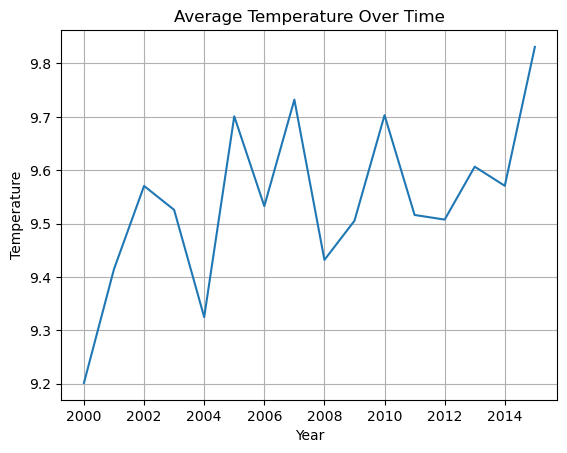

In [10]:
plt.figure()
plt.plot(data['year'], data['temperature'])
plt.title("Average Temperature Over Time")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.grid()
plt.show()

The graph illustrates the change in global average temperature over time.

A clear upward trend can be observed, indicating a gradual increase in global temperatures over the analyzed period. While there are small fluctuations from year to year, the overall direction remains positive.

This suggests a long-term warming pattern, which is consistent with global climate change observations.

Short-term variations may be influenced by natural factors, but the long-term trend highlights a steady increase in temperature.

## $ \ce{CO2} $ Emission trend

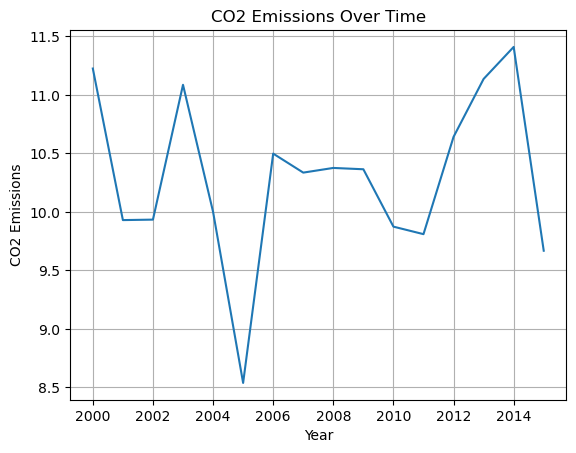

In [11]:
plt.figure()
plt.plot(data['year'], data['co2'])
plt.title("CO2 Emissions Over Time")
plt.xlabel("Year")
plt.ylabel("CO2 Emissions")
plt.grid()
plt.show()

The graph shows how $ \ce{CO2} $ emissions have changed over time.

We observe that emissions fluctuate across the years rather than following a perfectly smooth trend. There is a noticeable drop around 2005, followed by a recovery and gradual increase in later years.

In the period after 2010, emissions generally increase, reaching a peak around 2014, before slightly decreasing again.

These fluctuations may be influenced by economic activity, policy changes, or differences between countries included in the dataset.

Overall, despite short-term variations, the data suggests a general tendency toward increasing $ \ce{CO2} $ emissions over time.

This variability highlights the importance of analyzing long-term trends rather than individual yearly values.

## Temperature Distribution

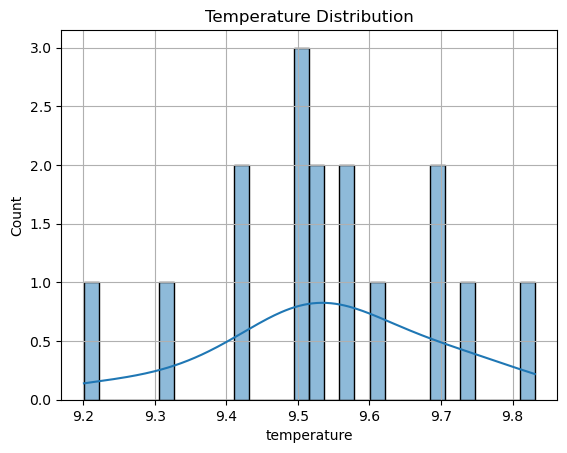

In [12]:
import seaborn as sns
plt.figure()
sns.histplot(data['temperature'], bins=30, kde=True)
plt.title("Temperature Distribution")
plt.grid()
plt.show()

The histogram shows the distribution of temperature values across the analyzed period.

Most temperature values are concentrated within a relatively narrow range, centered around approximately 9.4–9.7°C. This indicates that while temperatures are increasing over time, the overall variation remains moderate.

The shape of the distribution appears approximately normal, suggesting that extreme temperature values are relatively rare.

This distribution supports the observation that global temperature changes are gradual rather than abrupt.

The relatively tight clustering of values indicates stability in short-term variations, despite the long-term upward trend.

## Moving Average

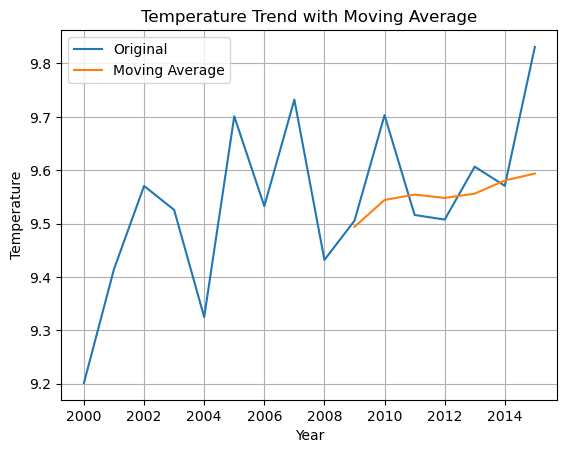

In [13]:
data['temp_moving_avg'] = data['temperature'].rolling(window=10).mean()

plt.figure()
plt.plot(data['year'], data['temperature'], label='Original')
plt.plot(data['year'], data['temp_moving_avg'], label='Moving Average')
plt.legend()
plt.title("Temperature Trend with Moving Average")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.grid()
plt.show()

The graph compares the original temperature values with a moving average.

The original data shows fluctuations from year to year, reflecting short-term variations. However, the moving average smooths these fluctuations and reveals the underlying trend.

The moving average shows a gradual increase in temperature over time, indicating a long-term warming pattern.

This demonstrates that while yearly temperatures may vary, the overall trend is consistently increasing.

The moving average helps highlight long-term trends by reducing the impact of short-term variability.

## Correlation Analysis

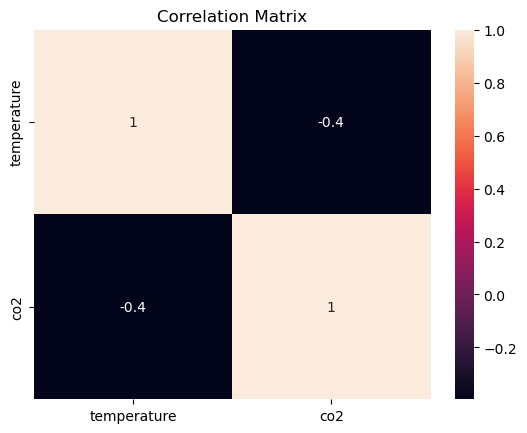

In [14]:
corr = data[['temperature', 'co2']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows a moderate negative relationship between $ \ce{CO2} $ emissions and temperature (correlation ≈ -0.4).

This result is somewhat unexpected, as higher $ \ce{CO2} $ emissions are generally associated with increasing temperatures.

However, this can be explained by several factors:
- The dataset covers a relatively short time period
- Data is aggregated and may contain noise
- Temperature is influenced by multiple variables beyond $ \ce{CO2} $ emissions

Therefore, while the correlation in this dataset appears negative, it does not necessarily contradict the broader understanding of climate change.

This highlights the importance of careful interpretation of statistical results in real-world data analysis.

## Regression Model

In [15]:
from sklearn.linear_model import LinearRegression

X = data[['co2']]
y = data['temperature']

model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


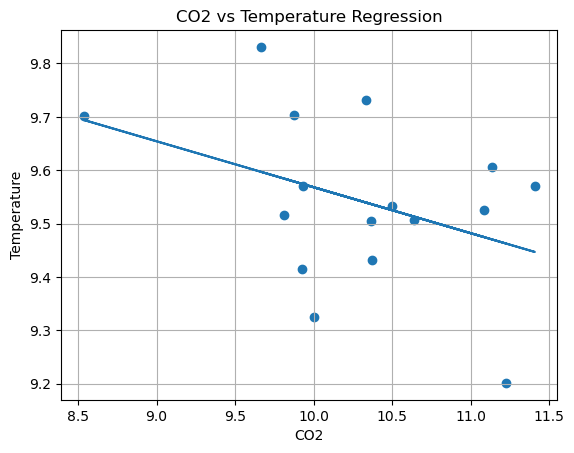

In [16]:
plt.figure()
plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.title("CO2 vs Temperature Regression")
plt.xlabel("CO2")
plt.ylabel("Temperature")
plt.grid()
plt.show()

In [17]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: -0.08614367714298392
Intercept: 10.429461507027135


## Regression Equation

The estimated regression model is:

$$
y = 10.43 - 0.086x
$$

where:
- $y$ is temperature  
- $x$ is CO₂ emissions  
- $\beta_0 \approx 10.43$ is the intercept  
- $\beta_1 \approx -0.086$ is the slope  

A linear regression model was used to examine the relationship between $ \ce{CO2} $ emissions and temperature.

The model shows a negative slope $\beta_0 \approx 10.43$, indicating a slight decrease in temperature as $ \ce{CO2} $ emissions increase in this dataset.

The intercept $\beta_1 \approx -0.086$ represents the theoretical temperature when $ \ce{CO2} $ emissions are zero.

However, the relationship is weak, and the data points are widely scattered around the regression line. This suggests that CO₂ alone does not fully explain temperature changes in this dataset.

These results should be interpreted with caution, as temperature is influenced by multiple factors and the dataset covers a limited time period.

The regression model highlights the importance of considering additional variables when analyzing climate data.

## Key Insight

The analysis demonstrates that real-world data may not always produce expected results.

This highlights the importance of careful interpretation and critical thinking in data science.

## Conclusion

This project analyzed global temperature trends and $ \ce{CO2} $  emissions using real-world datasets.

The results show that global temperatures exhibit a gradual increasing trend over time, indicating a long-term warming pattern. $ \ce{CO2} $  emissions also display variability, with an overall tendency to increase across the analyzed period.

The correlation analysis revealed a moderate negative relationship between temperature and $ \ce{CO2} $ emissions in this dataset. This indicates that the relationship between the two variables is not strongly linear within the observed time frame.

The linear regression model further confirmed this result, showing a slight negative slope. The data points are dispersed around the regression line, suggesting that CO₂ emissions alone do not fully determine temperature changes in this dataset.

Overall, the analysis demonstrates how data preprocessing, visualization, and statistical modeling can be used to explore relationships between environmental variables.

The findings highlight that the relationship between environmental variables can be complex.